In [1]:
import pandas as pd
import numpy as np


In [ ]:
# Carga de URL del dataset
url = 'https://raw.githubusercontent.com/Cristian-Eric-Falco/siniestros_viales_datos/refs/heads/main/siniestros_viales_victimas.csv'

# Leemos el dataset
df = pd.read_csv(url)



In [ ]:

# Muestra las primeras 5 filas
display(df.head())

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0000647,2019-01-01,2019,MOTO,M,54,GRAVE,SD,NaN
1,LC-2019-0000600,2019-01-01,2019,SD,F,1,LEVE,SD,NaN
2,LC-2019-0000136,2019-01-01,2019,SD,F,21,LEVE,SD,NaN
3,LC-2019-0000082,2019-01-01,2019,SD,F,32,LEVE,SD,NaN
4,LC-2019-0000194,2019-01-01,2019,SD,F,33,LEVE,SD,NaN


In [ ]:
# Mostrar tipo y cantidad de datos
print("\nData types:")
display(df.info())


Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62076 entries, 0 to 62075
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id_siniestro                 62076 non-null  object
 1   fecha_siniestro              62076 non-null  object
 2   anio_siniestro               62076 non-null  int64 
 3   modo_desplazamiento_victima  62076 non-null  object
 4   sexo_victima                 62076 non-null  object
 5   edad_victima                 62076 non-null  object
 6   GRAVEdad_victima             62076 non-null  object
 7   rol_victima                  61865 non-null  object
 8   fecha_fallecimiento_victima  610 non-null    object
dtypes: int64(1), object(8)
memory usage: 4.3+ MB


None

In [ ]:
# Estandarizar nombres de columnas: todo a minúsculas y sin espacios extra
df.columns = df.columns.str.lower().str.strip()

# Verificamos cómo quedaron los nombres
print("Nombres de columnas estandarizados:")
print(df.columns.tolist())

Nombres de columnas estandarizados:
['id_siniestro', 'fecha_siniestro', 'anio_siniestro', 'modo_desplazamiento_victima', 'sexo_victima', 'edad_victima', 'gravedad_victima', 'rol_victima', 'fecha_fallecimiento_victima']


Valores en registros de variables cualitativas

In [ ]:
def mostrar_valores_unicos(df, columnas):
    print("--- INSPECCIÓN DE VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ---")
    for col in columnas:
        # .unique() extrae solo los valores distintos (incluyendo NaN)
        valores_distintos = df[col].unique()

        print(f"\nValores únicos para la columna '{col}':")
        # Lo convertimos a lista para que la visualización en consola sea más limpia
        print(list(valores_distintos))

# Definimos tus columnas
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']

# Llamamos a la función
mostrar_valores_unicos(df, columnas_cat)

--- INSPECCIÓN DE VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS ---

Valores únicos para la columna 'gravedad_victima':
['GRAVE', 'LEVE', 'MORTAL']

Valores únicos para la columna 'sexo_victima':
['M', 'F', 'SD']

Valores únicos para la columna 'rol_victima':
['SD', 'CONDUCTOR', 'CICLISTA', 'PEATON', 'PASAJERO', 'Conductor', 'sd', 'conductor', nan]

Valores únicos para la columna 'modo_desplazamiento_victima':
['MOTO', 'SD', 'BICICLETA', 'AUTO', 'TAXI', 'PEATON', 'TRANSPORTE PUBLICO', 'UTILITARIO', 'CAMION', 'MONOPATIN', 'MOVIL', 'OTRO', 'moto', 'auto', 'monopatin', 'camion', 'peaton', 'MIXTO']


In [ ]:
def estandarizar_registros(df, columnas_categoricas):
    """
    Convierte todos los valores de las columnas categóricas a mayúsculas
    y elimina espacios extra para evitar duplicados como 'moto' y 'MOTO'.
    """
    df_clean = df.copy()
    for col in columnas_categoricas:
        if col in df_clean.columns:
            # Convertimos a string, pasamos a mayúsculas y borramos espacios en los extremos
            df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()
            # Al convertir a string, los NaN se vuelven la palabra 'NAN'. Lo revertimos:
            df_clean[col] = df_clean[col].replace('NAN', np.nan)
    return df_clean

# Ejecutamos la función sobre nuestro dataframe
cols_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']
df = estandarizar_registros(df, cols_cat)

# Verificamos rápidamente que se haya solucionado (ejemplo con modo_desplazamiento)
print(df['modo_desplazamiento_victima'].value_counts())

modo_desplazamiento_victima
SD                    21874
MOTO                  17466
PEATON                 6582
AUTO                   6204
BICICLETA              4964
TRANSPORTE PUBLICO     2913
UTILITARIO              652
TAXI                    597
MOVIL                   333
CAMION                  184
MONOPATIN               159
OTRO                     75
MIXTO                    73
Name: count, dtype: int64


Definicion de funciones para deteccion de valores faltantes, estandarizacion y transformacion a valores nulos.

In [ ]:
def detectar_valores_sd(df):
    """Cuenta la cantidad de valores 'SD' en columnas de tipo texto."""
    print("--- Conteo de valores 'SD' por columna ---")
    sd_totales = 0
    for column in df.select_dtypes(include=['object']).columns:
        sd_count = (df[column] == 'SD').sum()
        if sd_count > 0:
            print(f"Columna '{column}': {sd_count} registros con 'SD'")
            sd_totales += sd_count
    if sd_totales == 0:
        print("No se encontraron valores 'SD'.")
    print("-" * 40)

def identificar_duplicados(df, columna_id):
    """Identifica y muestra registros duplicados basados en una columna."""
    duplicados = df[df.duplicated(subset=[columna_id], keep=False)]
    if not duplicados.empty:
        print(f"--- Se encontraron {len(duplicados)} registros con '{columna_id}' duplicado ---")
        display(duplicados.sort_values(by=columna_id).head()) # Mostramos solo los primeros para no saturar
    else:
        print(f"--- No hay valores duplicados en la columna '{columna_id}' ---")

def estandarizar_nulos_y_tipos(df):
    # 1. Aislamos solo las columnas de texto para evitar que Pandas falle
    # silenciosamente al chocar con números o fechas
    cols_texto = df.select_dtypes(include=['object', 'string']).columns

    # 2. Reemplazamos directamente sobre esas columnas (sin regex, más rápido y seguro)
    # Incluimos variaciones comunes de espacios o mayúsculas por precaución
    variantes_sd = ['SD', 'SD ', ' SD', 'sd', 'Sd']
    df[cols_texto] = df[cols_texto].replace(variantes_sd, np.nan)

    # 3. Conversiones de tipos
    if 'edad_victima' in df.columns:
        df['edad_victima'] = pd.to_numeric(df['edad_victima'], errors='coerce')

    if 'fecha_siniestro' in df.columns:
        df['fecha_siniestro'] = pd.to_datetime(df['fecha_siniestro'], errors='coerce')

    return df

In [ ]:
print("=== FASE 1: ANÁLISIS INICIAL (DATOS CRUDOS) ===")
detectar_valores_sd(df)
identificar_duplicados(df, 'id_siniestro')

print("\n=== FASE 2: TRANSFORMACIÓN Y LIMPIEZA ===")
# Aplicamos la estandarización aislando los textos y reasignamos al DataFrame
df_limpio = estandarizar_nulos_y_tipos(df)
print("Transformación de tipos y limpieza de 'SD' completada.")

print("\n=== FASE 3: VERIFICACIÓN POST-PROCESAMIENTO ===")
# 3.1 Verificamos que el reemplazo funcionó (debería decir que no hay 'SD')
print("-> Re-evaluando valores 'SD':")
detectar_valores_sd(df_limpio)

# 3.2 Revisamos que los tipos de datos (como el float/Int64 de la edad o el datetime) estén correctos
print("\n-> Tipos de datos actualizados:")
display(df_limpio.info())

# 3.3 Verificamos la cantidad total de nulos (NaN) reales con los que vas a trabajar
print("\n-> Conteo final de nulos (NaN) por columna:")
display(df_limpio.isnull().sum())

=== FASE 1: ANÁLISIS INICIAL (DATOS CRUDOS) ===
--- Conteo de valores 'SD' por columna ---
Columna 'modo_desplazamiento_victima': 21874 registros con 'SD'
Columna 'sexo_victima': 11054 registros con 'SD'
Columna 'edad_victima': 16755 registros con 'SD'
Columna 'rol_victima': 49992 registros con 'SD'
----------------------------------------
--- Se encontraron 13720 registros con 'id_siniestro' duplicado ---


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,fecha_fallecimiento_victima
918,HC-2019-0069533,2019-02-02,2019,PEATON,M,59,MORTAL,PEATON,2019-2-2
919,HC-2019-0069533,2019-02-02,2019,PEATON,M,SD,MORTAL,PEATON,2019-2-2
1490,HC-2019-0108835,2019-02-20,2019,SD,F,40,LEVE,SD,NaN
1476,HC-2019-0108835,2019-02-20,2019,PEATON,M,39,MORTAL,PEATON,2019-3-2
1511,HC-2019-0108835,2019-02-20,2019,SD,M,40,LEVE,SD,NaN



=== FASE 2: TRANSFORMACIÓN Y LIMPIEZA ===
Transformación de tipos y limpieza de 'SD' completada.

=== FASE 3: VERIFICACIÓN POST-PROCESAMIENTO ===
-> Re-evaluando valores 'SD':
--- Conteo de valores 'SD' por columna ---
No se encontraron valores 'SD'.
----------------------------------------

-> Tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62076 entries, 0 to 62075
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_siniestro                 62076 non-null  object        
 1   fecha_siniestro              62076 non-null  datetime64[ns]
 2   anio_siniestro               62076 non-null  int64         
 3   modo_desplazamiento_victima  40202 non-null  object        
 4   sexo_victima                 51022 non-null  object        
 5   edad_victima                 45320 non-null  float64       
 6   gravedad_victima             62076 non-nu

None


-> Conteo final de nulos (NaN) por columna:


,0
id_siniestro,0
fecha_siniestro,0
anio_siniestro,0
modo_desplazamiento_victima,21874
sexo_victima,11054
edad_victima,16756
gravedad_victima,0
rol_victima,50203
fecha_fallecimiento_victima,61466


In [ ]:
display(df.head())

,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0000647,2019-01-01,2019,MOTO,M,54.0,GRAVE,NaN,NaN
1,LC-2019-0000600,2019-01-01,2019,NaN,F,1.0,LEVE,NaN,NaN
2,LC-2019-0000136,2019-01-01,2019,NaN,F,21.0,LEVE,NaN,NaN
3,LC-2019-0000082,2019-01-01,2019,NaN,F,32.0,LEVE,NaN,NaN
4,LC-2019-0000194,2019-01-01,2019,NaN,F,33.0,LEVE,NaN,NaN


Encontramos anteriormente 13720 registros con 'id_siniestro' duplicado. Esto no significa que todos esos registros son errores, ya que posiblemente, un mismo id_siniestro podria captar un accidente que implico a varias personas.

Por lo tanto, vamos a identificar registros que sean exactamente iguales y estos los consideraremos errores de carga.

In [ ]:
def identificar_duplicados(df, columna_id):
    """
    Identifica registros duplicados diferenciando entre filas idénticas
    y colisiones de ID (mismo accidente, múltiples víctimas).
    """
    # 1. Buscamos duplicados donde TODA la fila es exactamente igual (Error de carga)
    duplicados_exactos = df[df.duplicated(keep=False)]

    # 2. Buscamos duplicados solo por el ID del siniestro
    duplicados_id = df[df.duplicated(subset=[columna_id], keep=False)]

    print("--- ANÁLISIS DE DUPLICADOS ---")

    if not duplicados_exactos.empty:
        print(f"ALERTA: Se encontraron {len(duplicados_exactos)} filas EXACTAMENTE idénticas (posible error de sistema/carga).")
    else:
        print("No hay filas 100% duplicadas.")

    if not duplicados_id.empty:
        ids_unicos_repetidos = duplicados_id[columna_id].nunique()
        print(f"INFO: Hay {len(duplicados_id)} registros compartiendo {ids_unicos_repetidos} IDs de siniestro únicos.")
        print("    (Esto es normal si hay siniestros con múltiples víctimas).")
        print("\nEjemplo de un siniestro con múltiples registros:")

        # Mostramos todos los registros del primer ID duplicado que encontremos para analizarlo
        primer_id_duplicado = duplicados_id[columna_id].iloc[0]
        display(df[df[columna_id] == primer_id_duplicado])
    else:
        print(f"--- No hay valores duplicados en la columna '{columna_id}' ---")

In [ ]:
identificar_duplicados(df, 'id_siniestro')

--- ANÁLISIS DE DUPLICADOS ---
ALERTA: Se encontraron 2124 filas EXACTAMENTE idénticas (posible error de sistema/carga).
INFO: Hay 13720 registros compartiendo 5708 IDs de siniestro únicos.
    (Esto es normal si hay siniestros con múltiples víctimas).

Ejemplo de un siniestro con múltiples registros:


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,fecha_fallecimiento_victima
2,LC-2019-0000136,2019-01-01,2019,NaN,F,21.0,LEVE,NaN,NaN
10,LC-2019-0000136,2019-01-01,2019,NaN,M,21.0,LEVE,NaN,NaN


In [ ]:
def eliminar_duplicados_exactos(df):
    """
    Elimina registros donde toda la fila es exactamente igual a otra,
    manteniendo solo la primera aparición.
    Altera el DataFrame directamente en memoria (inplace).
    """
    # Registramos el tamaño original para el reporte
    filas_antes = len(df)

    # Eliminamos los duplicados exactos aplicando inplace=True
    df.drop_duplicates(inplace=True)

    # Calculamos el impacto
    filas_despues = len(df)
    eliminados = filas_antes - filas_despues

    print("--- LIMPIEZA DE DUPLICADOS ---")
    if eliminados > 0:
        print(f"Éxito: Se eliminaron {eliminados} filas exactamente duplicadas.")
        print(f"El dataset se redujo de {filas_antes} a {filas_despues} registros útiles.")
    else:
        print("No se encontraron duplicados exactos para eliminar.")

# --- Cómo usarlo en tu pipeline ---
# Simplemente llamas a la función pasándole tu variable df.
# No necesitas hacer "df = ..." porque el cambio es interno.


In [ ]:
eliminar_duplicados_exactos(df)

--- LIMPIEZA DE DUPLICADOS ---
Éxito: Se eliminaron 1166 filas exactamente duplicadas.
El dataset se redujo de 62076 a 60910 registros útiles.


Una vez habiendo usado el id_siniestro para encontrar duplicados, lo eliminamos ya que no aporta valor predictivo. Tambien eliminamos la fecha de fallecimiento de la victima, por ser informacion redundante y se correlaciona de forma perfecta con la clasificacion mortal en la columna gravedad_victima

id_siniestro: Es simplemente un identificador único (ruido). Los algoritmos podrían intentar memorizar estos números por accidente, lo cual no aporta ningún valor predictivo.

fecha_fallecimiento_victima: Eliminar esta columna es un requisito absoluto para evitar la fuga de información (Data Leakage). Si le dejamos esta columna al modelo, el algoritmo aprenderá a hacer trampa: si la fila tiene una fecha, automáticamente sabrá que el accidente es "MORTAL", arruinando el propósito de predecir la gravedad en el momento del impacto.

In [ ]:
# Definimos las columnas que no aportan valor predictivo o generan Data Leakage
columnas_a_eliminar = ['id_siniestro', 'fecha_fallecimiento_victima']

# Eliminamos las columnas del DataFrame de forma permanente
df = df.drop(columns=columnas_a_eliminar)

print("Columnas eliminadas correctamente.")
print("Columnas actuales en el dataset:", df.columns.tolist())

Columnas eliminadas correctamente.
Columnas actuales en el dataset: ['fecha_siniestro', 'anio_siniestro', 'modo_desplazamiento_victima', 'sexo_victima', 'edad_victima', 'gravedad_victima', 'rol_victima']


In [ ]:
print("--- INSPECCIÓN DE VALORES EN COLUMNAS CATEGÓRICAS")
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']

for col in columnas_cat:
    print(f"\nConteo de valores para la columna '{col}':")
    # Mostramos los valores únicos, sus conteos y mantenemos los NaN a la vista
    print(df[col].value_counts(dropna=False))

--- INSPECCIÓN DE VALORES EN COLUMNAS CATEGÓRICAS

Conteo de valores para la columna 'gravedad_victima':
gravedad_victima
LEVE      57856
GRAVE      2444
MORTAL      610
Name: count, dtype: int64

Conteo de valores para la columna 'sexo_victima':
sexo_victima
M      33219
F      17092
NaN    10599
Name: count, dtype: int64

Conteo de valores para la columna 'rol_victima':
rol_victima
NaN          49096
PEATON        6531
CICLISTA      4955
CONDUCTOR      268
PASAJERO        60
Name: count, dtype: int64

Conteo de valores para la columna 'modo_desplazamiento_victima':
modo_desplazamiento_victima
NaN                   21283
MOTO                  17342
PEATON                 6532
AUTO                   5997
BICICLETA              4955
TRANSPORTE PUBLICO     2811
UTILITARIO              623
TAXI                    582
MOVIL                   309
CAMION                  180
MONOPATIN               159
MIXTO                    70
OTRO                     67
Name: count, dtype: int64


VISUALIZACIONES




Análisis Univariado

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_variable_numerica(df, columna):
    """
    Crea un panel con un histograma y un boxplot para analizar
    la distribución y detectar outliers en una variable numérica.
    """
    # Filtramos los nulos solo para el gráfico, para que no tire error
    datos_limpios = df[columna].dropna()

    # Configuramos la figura con dos subgráficos (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Histograma en el primer eje
    sns.histplot(datos_limpios, bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {columna}')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')

    # 2. Boxplot en el segundo eje para ver outliers
    sns.boxplot(x=datos_limpios, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot de {columna} (Detección de Outliers)')
    axes[1].set_xlabel(columna)

    plt.tight_layout()
    plt.show()

def analizar_variables_categoricas(df, columnas_categoricas):
    """
    Genera gráficos de barras horizontales para ver la frecuencia
    de las categorías en las variables seleccionadas.
    """
    for col in columnas_categoricas:
        plt.figure(figsize=(10, 4))
        # Usamos countplot para contar la frecuencia de cada categoría
        sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Frecuencia de categorías en: {col}')
        plt.xlabel('Cantidad')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

--- ANÁLISIS DE LA EDAD DE LAS VÍCTIMAS ---


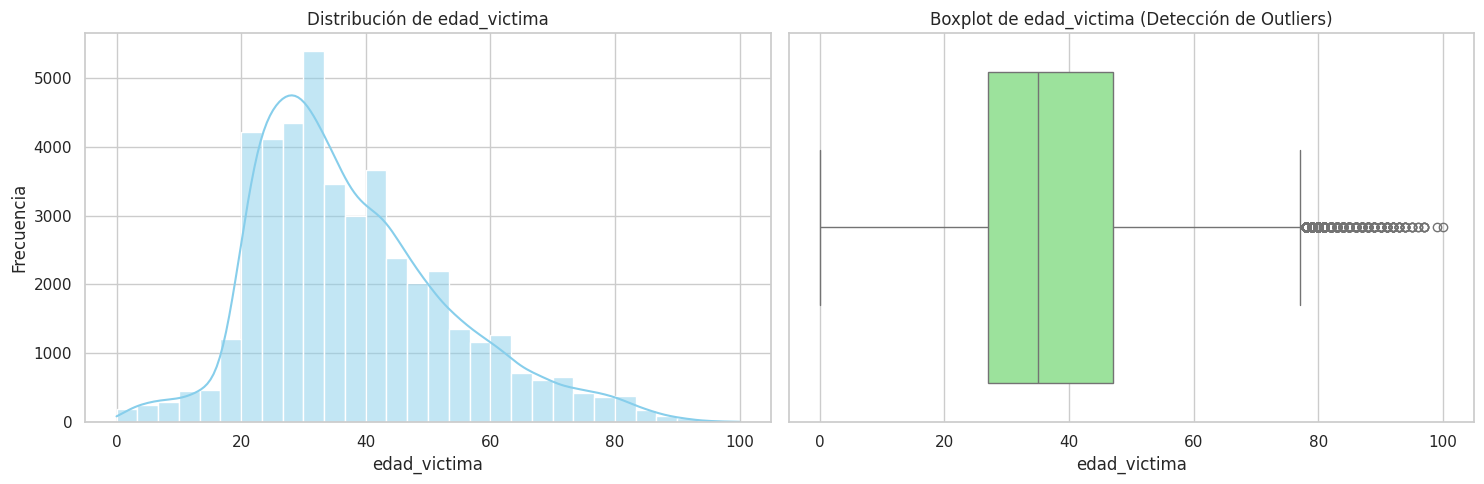


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---


/tmp/ipykernel_40332/1435013833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


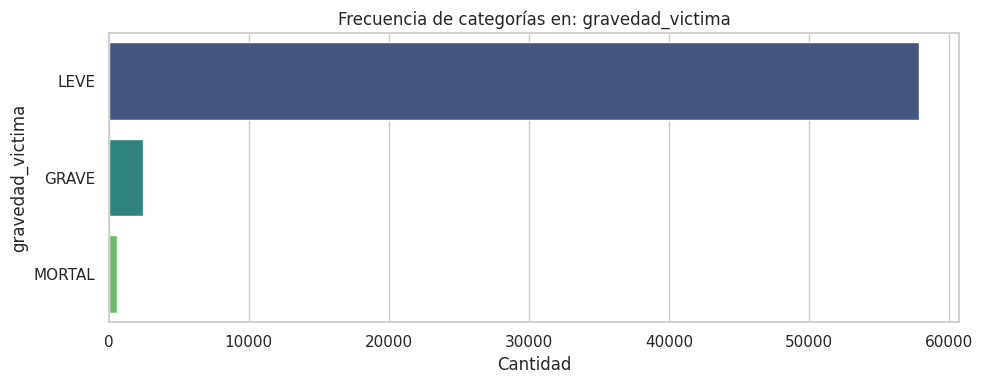

/tmp/ipykernel_40332/1435013833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


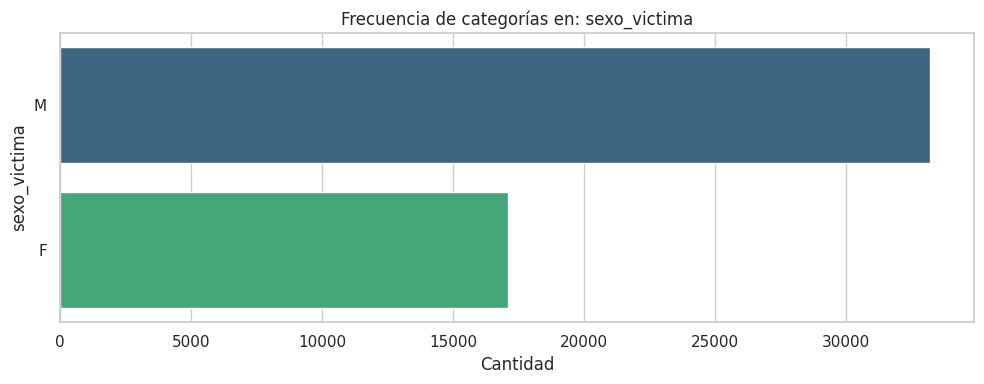

/tmp/ipykernel_40332/1435013833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


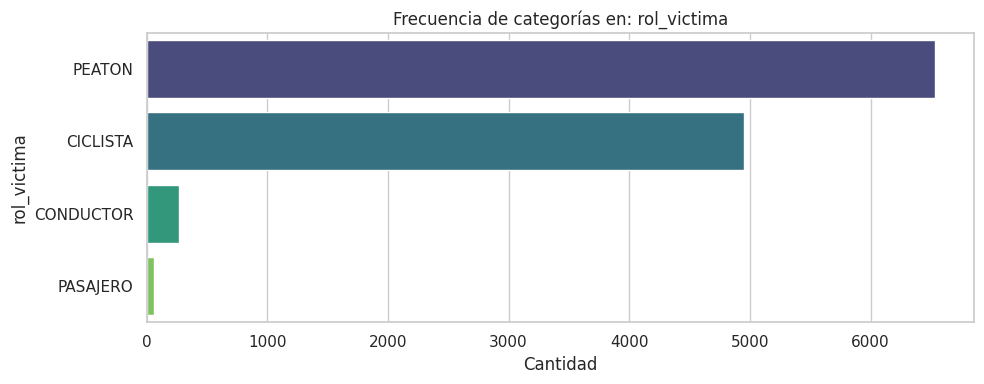

/tmp/ipykernel_40332/1435013833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


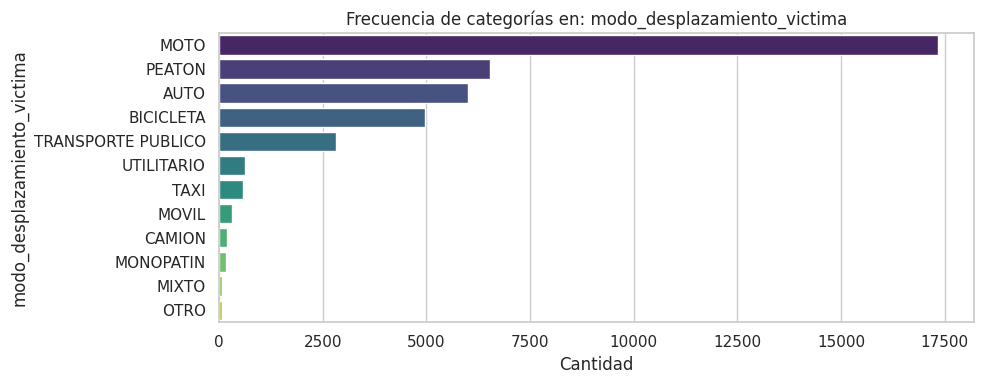

In [ ]:
# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")

# 1. Análisis de Outliers y Distribución (Numérica)
print("--- ANÁLISIS DE LA EDAD DE LAS VÍCTIMAS ---")
analizar_variable_numerica(df, 'edad_victima')

# 2. Análisis de Variables Categóricas Clave
print("\n--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
columnas_a_graficar = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']

analizar_variables_categoricas(df, columnas_a_graficar)

Edad de las victimas: Distribución normal con sesgo positivo (cola hacia la derecha), media cercana a los 30. Outliers entre 80 y 100 años.

Gravedad de la victima: Gran mayoría leves, pocos graves, muy pocos mortales.
Tenemos un problema grave de clases desbalanceadas (imbalanced dataset). Si el modelo predice siempre "LEVE", va a acertar el 90% de las veces, pero fallará miserablemente en predecir los casos mortales, que es justamente lo que debemos predecir. Cuando lleguemos a la fase de algoritmos, tendremos que usar técnicas específicas (como SMOTE, o pesos en las clases) para compensar esto.

Frecuencia categorias sexo: Doble de hombres que de mujeres. Posiblemente influenciado por la tasa de personas que manejan.
A esto en estadística se lo llama "variable de confusión" o falta de normalización por "tasa de exposición". Es decir, que no necesariamente en la realidad ser hombre tenga mas probabilidad de accidente.

ANALISIS BIVARIADO

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def bivariado_categoricas_vs_target(df, columnas_cat, target):
    """
    Genera gráficos de barras agrupadas para comparar variables categóricas
    contra la variable objetivo.
    """
    for col in columnas_cat:
        if col != target:  # Evitamos cruzar la variable objetivo consigo misma
            plt.figure(figsize=(12, 6))
            # Usamos 'hue' para dividir las barras según la gravedad
            sns.countplot(data=df, y=col, hue=target, palette='Set2')
            plt.title(f'Relación entre {col} y {target}')
            plt.xlabel('Cantidad de Víctimas')
            plt.ylabel(col)
            plt.legend(title='Gravedad', loc='lower right')
            plt.tight_layout()
            plt.show()

def bivariado_numerica_vs_target(df, col_num, target):
    """
    Genera un boxplot para ver cómo se distribuye una variable numérica
    en cada una de las categorías de la variable objetivo.
    """
    plt.figure(figsize=(10, 6))
    # El boxplot nos mostrará si la mediana de edad cambia según si es leve, grave o mortal
    sns.boxplot(data=df, x=target, y=col_num, palette='Set3')
    plt.title(f'Distribución de {col_num} según {target}')
    plt.xlabel('Gravedad de la Víctima')
    plt.ylabel(col_num)
    plt.tight_layout()
    plt.show()

--- ANÁLISIS BIVARIADO: CATEGÓRICAS VS GRAVEDAD ---


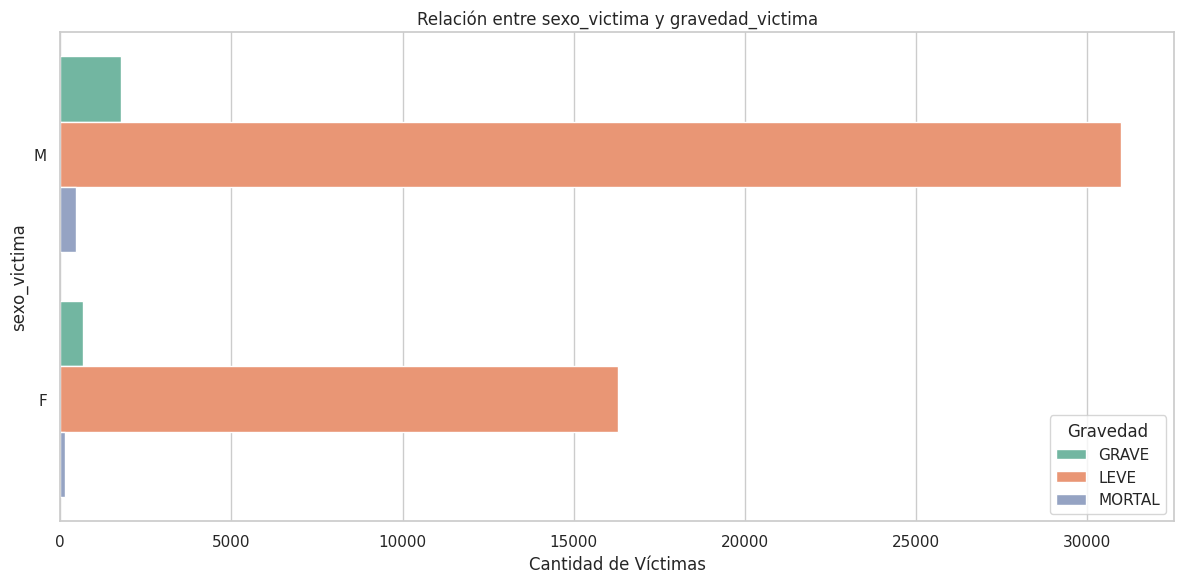

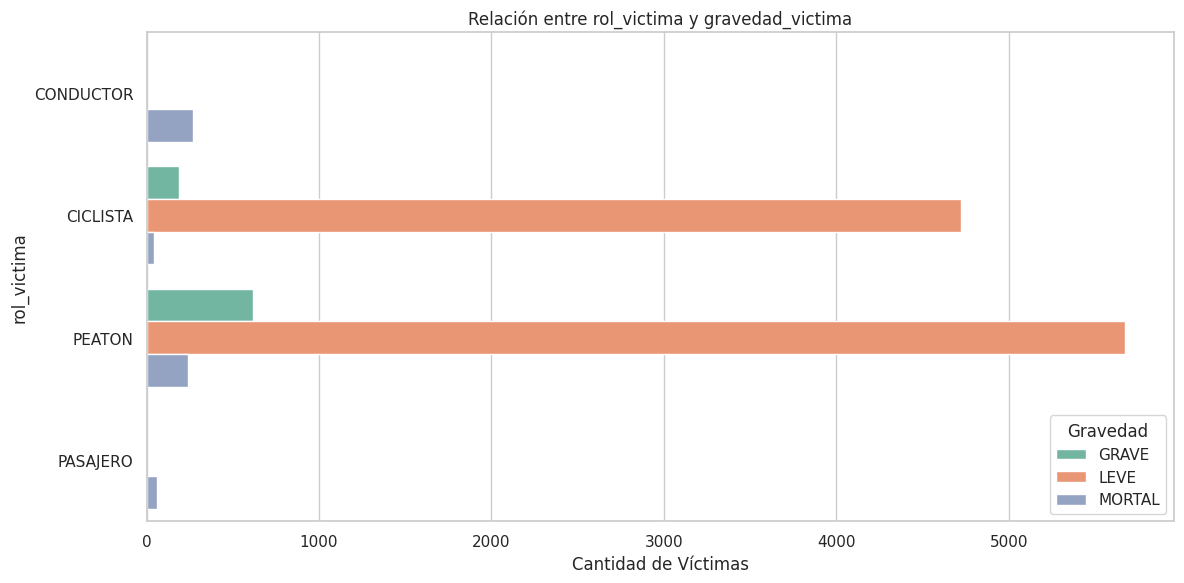

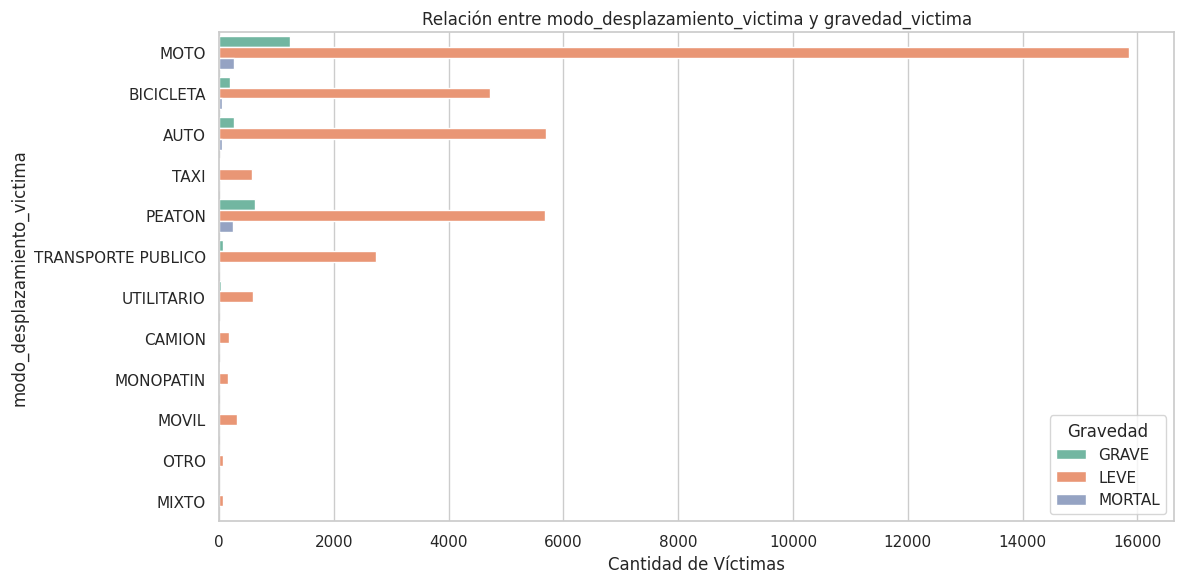


--- ANÁLISIS BIVARIADO: EDAD VS GRAVEDAD ---


/tmp/ipykernel_40332/3074657818.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col_num, palette='Set3')


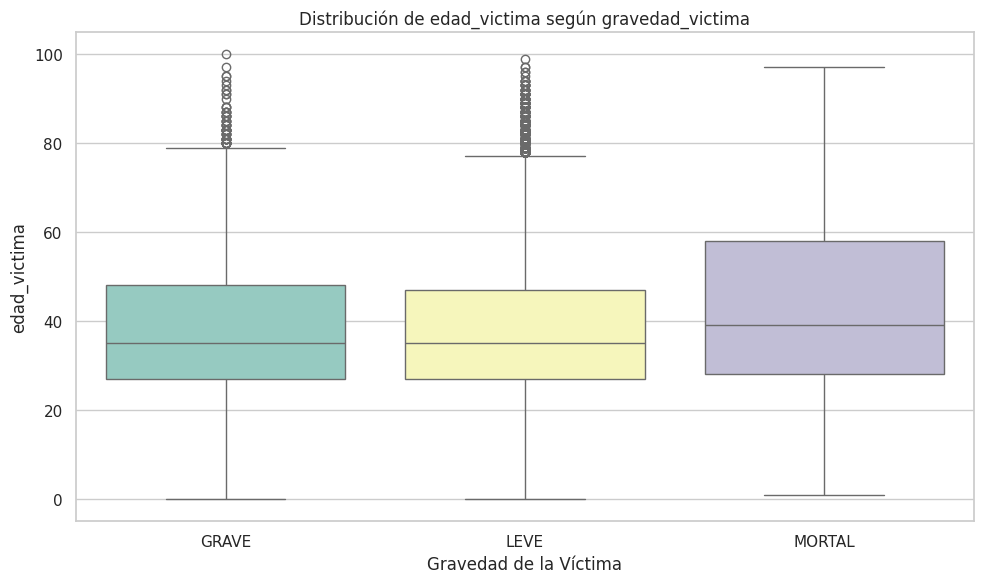

In [ ]:
sns.set_theme(style="whitegrid")

print("--- ANÁLISIS BIVARIADO: CATEGÓRICAS VS GRAVEDAD ---")
# Usamos la lista de columnas que ya teníamos
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']
target_col = 'gravedad_victima'

bivariado_categoricas_vs_target(df, columnas_cat, target_col)

print("\n--- ANÁLISIS BIVARIADO: EDAD VS GRAVEDAD ---")
bivariado_numerica_vs_target(df, 'edad_victima', target_col)

Resumen de Hallazgos Bivariados


Sexo vs. Gravedad: Se observa una mayor cantidad absoluta de víctimas de sexo masculino en comparación con el femenino en todos los niveles de gravedad. Sin embargo, la gran mayoría de los siniestros para ambos sexos resulta en lesiones LEVES, manteniendo una proporción visualmente similar entre los niveles de gravedad para ambos grupos.

Rol de la víctima vs. Gravedad: El rol de PEATON concentra una gran cantidad de víctimas con lesiones LEVES, pero destaca por ser la categoría que acumula la mayor cantidad absoluta de víctimas MORTALES en comparación con el resto de los roles (como CICLISTA o CONDUCTOR).

Modo de desplazamiento vs. Gravedad: Las categorías MOTO y AUTO agrupan la mayor cantidad de siniestros LEVES. No obstante, al observar la gravedad MORTAL, MOTO y PEATON son las que registran el mayor número de víctimas fatales. Por el contrario, la categoría AUTO, a pesar de su alto volumen total de accidentes, presenta una proporción mínima de casos mortales.

Edad vs. Gravedad: Las distribuciones de edad para las víctimas con lesiones LEVES y GRAVES presentan medianas similares (alrededor de los 30-35 años). En contraste, la distribución para accidentes MORTALES muestra un desplazamiento hacia edades más avanzadas, con una mediana cercana a los 40 años y un rango intercuartílico superior que se extiende hacia los 60 años, lo que indica una mayor incidencia de fatalidad en víctimas de mayor edad.

**Análisis Multivariado: Matriz de Correlación (Heatmap)**


Para poder hacer un mapa de calor las variables deben ser numericas. A continuacion transformamos la variable objetivo en LEVE=1, GRAVE=2 y MORTAL=3.

Las otras variables categoricas se les asigna valor numerico tambien pero solo para poder realizar el heatmap en este paso.


Como vemos, el coeficiente de Pearson no es muy util en variables que no son continuas, mas solo para evaluar algo de colinealidad entre rol_victima y modo_desplazamiento_victima.


Vamos a usar en cambio otros coeficientes de correlacion que nos sirven para variables de tipo cualitativo.


Como recordatorio rápido de la teoría que estamos aplicando:

Spearman: Evalúa si la relación es monotónica (si una sube, la otra sube, o viceversa), sin importar si es una línea recta. Es ideal para cruzar nuestra variable continua (edad_victima) con la ordinal (gravedad_victima mapeada a 1, 2, 3).

V de Cramér: Mide la fuerza de asociación entre dos variables estrictamente nominales (categóricas sin orden lógico, como sexo_victima y rol_victima). Nos devuelve un valor entre 0 y 1, donde 0 es nula asociación y 1 es asociación perfecta.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


def calcular_v_cramer(x, y):
    """Calcula el estadístico V de Cramér con corrección de sesgo."""
    matriz_confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(matriz_confusion)[0]
    n = matriz_confusion.sum().sum()
    phi2 = chi2 / n
    r, k = matriz_confusion.shape

    # Corrección de sesgo para V de Cramér
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    denominador = min((kcorr-1), (rcorr-1))
    if denominador == 0:
        return 0.0
    return np.sqrt(phi2corr / denominador)

def generar_heatmap_cramer(df, columnas_cat):
    """
    Genera una matriz de asociación para variables estrictamente nominales.
    """
    # SOLUCIÓN: Convertimos temporalmente a tipo 'object' para que fillna no falle
    # con las columnas de tipo 'category'
    df_cat = df[columnas_cat].astype(object).fillna('Desconocido')

    n = len(columnas_cat)
    matriz_cramer = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            matriz_cramer[i, j] = calcular_v_cramer(df_cat[columnas_cat[i]], df_cat[columnas_cat[j]])

    df_cramer_results = pd.DataFrame(matriz_cramer, index=columnas_cat, columns=columnas_cat)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cramer_results, annot=True, cmap='Blues', fmt=".2f", vmin=0, vmax=1, linewidths=0.5)
    plt.title("Asociación Categórica (V de Cramér)")
    plt.tight_layout()
    plt.show()

--- ANÁLISIS DE CORRELACIÓN AVANZADO ---

2. Ejecutando V de Cramér (Enfoque Nominal)...


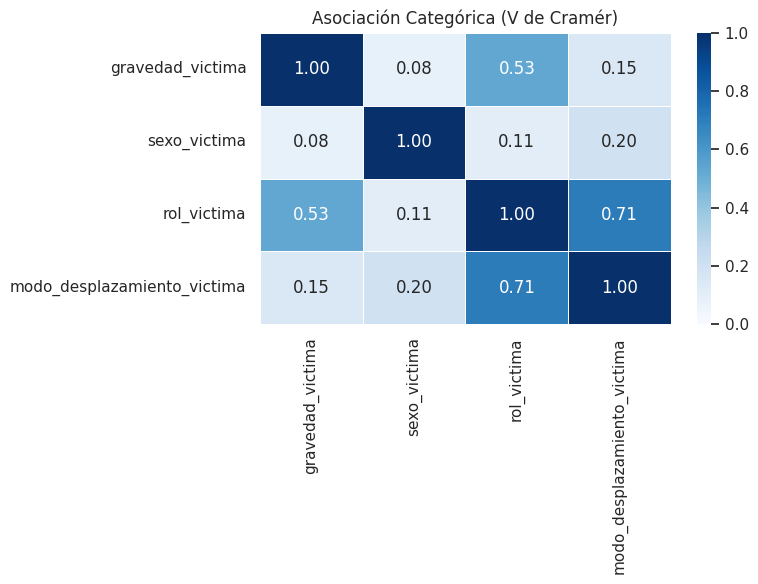

In [ ]:
print("--- ANÁLISIS DE CORRELACIÓN AVANZADO ---")
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima']
target_col = 'gravedad_victima'

print("\n2. Ejecutando V de Cramér (Enfoque Nominal)...")
generar_heatmap_cramer(df, columnas_cat)

Análisis de la V de Cramér
Al observar la matriz de asociación categórica (V de Cramér), saltan a la vista dos puntos críticos:

La Revelación (Rol vs. Gravedad = 0.53): Una asociación 0.53, es estadísticamente fuerte. Nos está diciendo de forma contundente que el rol de la víctima (ser peatón, conductor, ciclista) está altamente asociado con la gravedad del accidente. Esto confirma matemáticamente lo que veíamos en los gráficos de barras: el nivel de protección de la persona es un factor determinante para sobrevivir o no al siniestro.

La Confirmación de Multicolinealidad (Rol vs. Modo = 0.63): Esta asociación es muy alta. Como sospechábamos, el rol y el modo de desplazamiento nos están contando casi la misma historia (si el rol es ciclista, el modo es bicicleta).

Analisis de las variables en funcion del tiempo

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker # Fundamental para arreglar el eje X del primer gráfico

def analizar_tendencias_temporales(df, target):
    """
    Analiza la evolución temporal de los accidentes a nivel histórico,
    por mes del año y por día de la semana.
    """
    df_temp = df.copy()

    # Descartamos nulos en la fecha para evitar errores
    df_temp = df_temp.dropna(subset=['fecha_siniestro'])

    # 1. Extraemos características temporales útiles
    df_temp['año_mes'] = df_temp['fecha_siniestro'].dt.to_period('M').astype(str)

    dias = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
    df_temp['dia_semana'] = df_temp['fecha_siniestro'].dt.dayofweek.map(dias)

    # NUEVO: Extraemos el mes y lo mapeamos a texto
    meses = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
             7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
    df_temp['mes'] = df_temp['fecha_siniestro'].dt.month.map(meses)

    # --- Gráfico 1: Evolución Histórica (Línea de tiempo) ---
    plt.figure(figsize=(14, 6))
    evolucion = df_temp.groupby(['año_mes', target]).size().reset_index(name='cantidad')

    ax = sns.lineplot(data=evolucion, x='año_mes', y='cantidad', hue=target, marker='o', palette='Set2', linewidth=2)
    # MAGIA: Limitamos la cantidad de etiquetas en X para que no se pisen
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15))

    plt.title('Evolución Temporal de Siniestros Viales por Gravedad', fontsize=14)
    plt.xlabel('Año - Mes')
    plt.ylabel('Cantidad de Víctimas')
    plt.xticks(rotation=45)
    plt.legend(title='Gravedad')
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Accidentes por Mes del Año (Estacionalidad) ---
    plt.figure(figsize=(12, 6))
    orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                   'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

    sns.countplot(data=df_temp, x='mes', hue=target, order=orden_meses, palette='Set2')
    plt.title('Distribución de Siniestros por Mes del Año', fontsize=14)
    plt.xlabel('Mes')
    plt.ylabel('Cantidad de Víctimas')
    plt.xticks(rotation=45)
    plt.legend(title='Gravedad', loc='upper right')
    plt.tight_layout()
    plt.show()

    # --- Gráfico 3: Accidentes por Día de la Semana ---
    plt.figure(figsize=(12, 6))
    orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

    sns.countplot(data=df_temp, x='dia_semana', hue=target, order=orden_dias, palette='Set2')
    plt.title('Distribución de Siniestros por Día de la Semana', fontsize=14)
    plt.xlabel('Día de la Semana')
    plt.ylabel('Cantidad de Víctimas')
    plt.legend(title='Gravedad', loc='upper right')
    plt.tight_layout()
    plt.show()

--- ANÁLISIS TEMPORAL DE LOS SINIESTROS ---


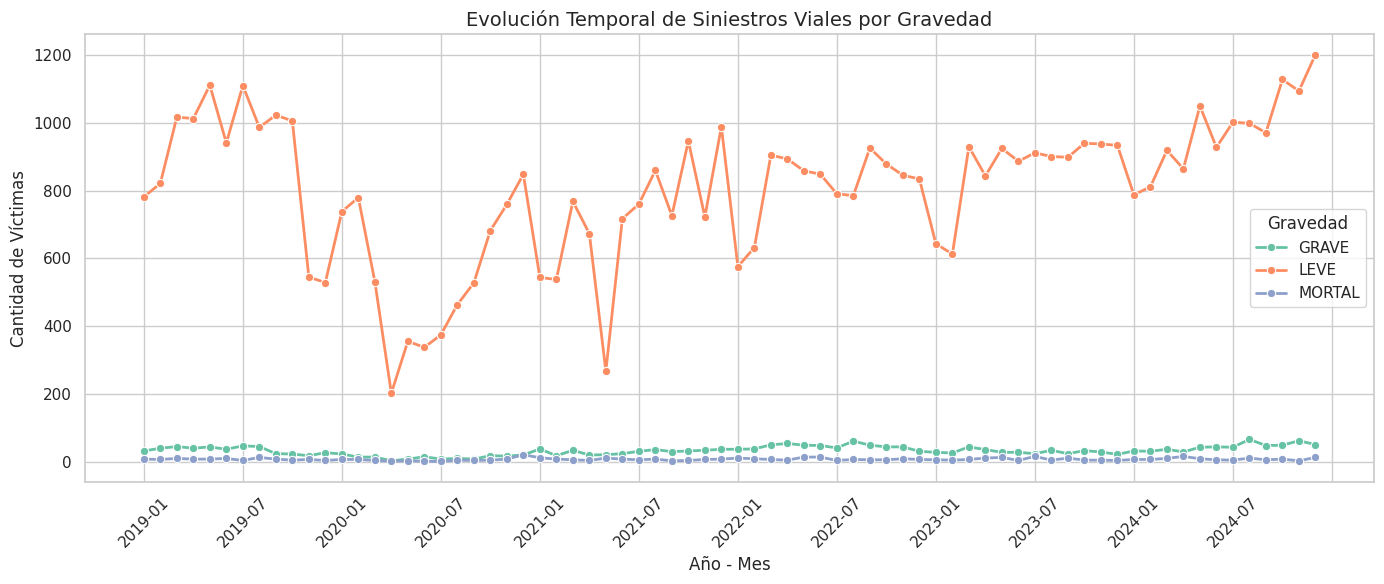

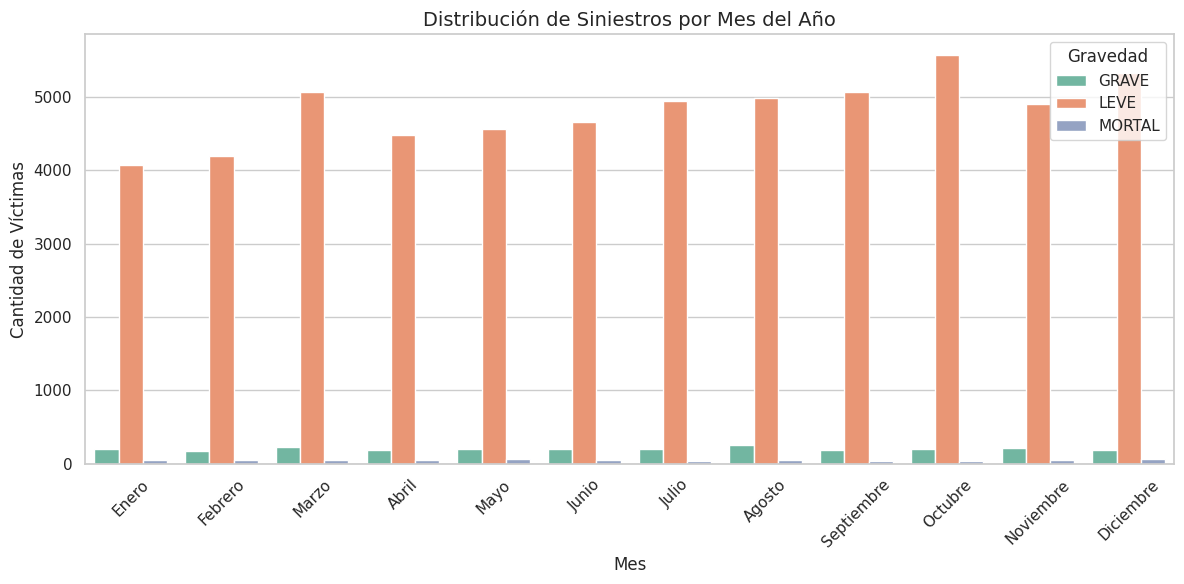

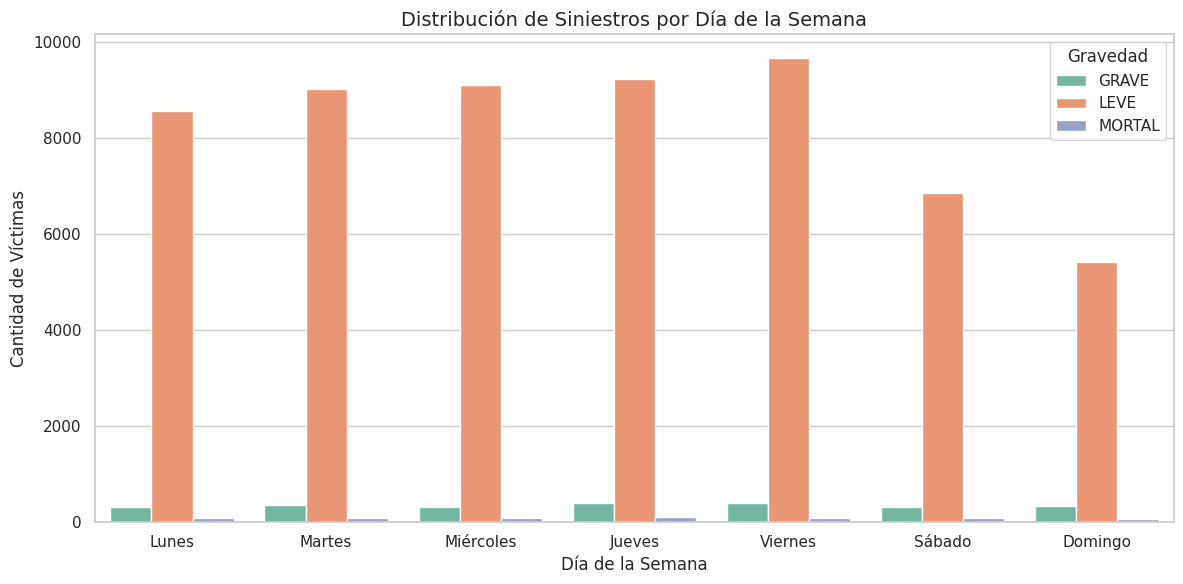

In [ ]:
print("--- ANÁLISIS TEMPORAL DE LOS SINIESTROS ---")
analizar_tendencias_temporales(df, 'gravedad_victima')

Distribución por día de la semana: Se observa un volumen significativamente mayor de siniestros viales durante los días hábiles (lunes a viernes) en comparación con los fines de semana. Los días de mayor accidentología total son los jueves y viernes. Los sábados y domingos presentan una marcada caída en la cantidad absoluta de víctimas.

Distribución estacional (Mes del año): Se identifica un patrón cíclico anual claro. Los meses de enero y febrero registran los volúmenes más bajos de siniestralidad del año, coincidiendo con el receso estival y la disminución del tráfico habitual. A partir de marzo se produce un incremento abrupto que se mantiene elevado, alcanzando sus picos máximos anuales durante los meses de octubre y noviembre. Este comportamiento estacional recurrente es el que genera el patrón en forma de "serrucho" o zigzag constante en la evolución a largo plazo.

Evolución histórica (El factor pandemia): El gráfico de líneas revela un patrón atípico fundamental: una caída abrupta y drástica en la cantidad de siniestros a partir de marzo/abril de 2020. Este valle coincide exactamente con el inicio de las restricciones de circulación por la pandemia de COVID-19. Posteriormente, se observa una tendencia de recuperación gradual a lo largo de 2021 y 2022, retomando y superando los niveles prepandemia hacia 2023 y 2024. Las lesiones graves y mortales, al ser volúmenes mucho menores, se mantienen visualmente como líneas planas en el fondo, indicando que la gran fluctuación temporal está impulsada casi exclusivamente por los siniestros leves.

INGENIERIA DE CARACTERISTICAS

Buscamos generar algunas nuevas columnas que ayuden a captar informacion que sirva para las predicciones.

Basándonos en lo que vimos en el EDA, podríamos crear estas características con alto poder predictivo:

Interacción Usuario-Vehículo Vulnerable (Binaria): Vimos que las motos, peatones y bicicletas concentran la mortalidad. Podemos crear una característica llamada es_usuario_vulnerable que valga 1 si el modo es MOTO, PEATON o BICICLETA, y 0 para el resto.

Interacción Temporal-Vehicular (Producto lógico): Vimos más accidentes los jueves/viernes. Podríamos crear una variable que sea el "producto" del riesgo: es_moto_fin_de_semana. Si el modelo nota que los motociclistas se accidentan más gravemente cerca del fin de semana, esta variable encapsula esa no-linealidad perfectamente.

Agrupación de Edad (Discretización): En lugar de usar la edad como un continuo que sube de a 1 año, podemos crear rangos etarios (es_adulto_mayor para > 65 años, es_joven para < 25). Multiplicar es_adulto_mayor por es_peaton crearía una característica fortísima, ya que la vulnerabilidad física de un adulto mayor impactado por un vehículo es un predictor casi seguro de gravedad alta.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

def aplicar_feature_engineering(df):
    """
    Crea nuevas variables predictivas (Feature Engineering) combinando
    la información existente y aplicando transformaciones cíclicas temporales
    para mejorar el rendimiento de los algoritmos.
    """
    df_fe = df.copy()

    # 1. Variable Binaria: Usuario Vulnerable
    vulnerables = ['MOTO', 'PEATON', 'BICICLETA']
    if 'modo_desplazamiento_victima' in df_fe.columns:
        df_fe['es_usuario_vulnerable'] = df_fe['modo_desplazamiento_victima'].isin(vulnerables).astype(int)

    # 2. Extracción de Fechas y Transformación Cíclica
    if 'fecha_siniestro' in df_fe.columns:
        # Aseguramos formato datetime
        df_fe['fecha_siniestro'] = pd.to_datetime(df_fe['fecha_siniestro'])

        # Extracciones lineales base
        df_fe['mes'] = df_fe['fecha_siniestro'].dt.month
        df_fe['dia_de_la_semana'] = df_fe['fecha_siniestro'].dt.dayofweek # 0=Lunes, 6=Domingo
        df_fe['hora_del_dia'] = df_fe['fecha_siniestro'].dt.hour

        # Variable Binaria: Fin de Semana (Viernes=4, Sábado=5, Domingo=6)
        dias_finde = [4, 5, 6]
        df_fe['es_fin_de_semana'] = df_fe['dia_de_la_semana'].isin(dias_finde).astype(int)

        # --- TRANSFORMACIONES CÍCLICAS ---
        # Meses (divisor: 12)
        df_fe['mes_sin'] = np.sin(2 * np.pi * df_fe['mes'] / 12)
        df_fe['mes_cos'] = np.cos(2 * np.pi * df_fe['mes'] / 12)

        # Días de la semana (divisor: 7)
        df_fe['dia_sin'] = np.sin(2 * np.pi * df_fe['dia_de_la_semana'] / 7)
        df_fe['dia_cos'] = np.cos(2 * np.pi * df_fe['dia_de_la_semana'] / 7)

        # Horas del día (divisor: 24)
        df_fe['hora_sin'] = np.sin(2 * np.pi * df_fe['hora_del_dia'] / 24)
        df_fe['hora_cos'] = np.cos(2 * np.pi * df_fe['hora_del_dia'] / 24)

    # 3. Discretización de Edad: Creación de Grupos Etarios
    bins_edad = [0, 25, 60, 100] # Límites de los rangos
    labels_edad = ['Joven', 'Adulto', 'Adulto Mayor']
    if 'edad_victima' in df_fe.columns:
        df_fe['grupo_etario'] = pd.cut(df_fe['edad_victima'], bins=bins_edad, labels=labels_edad)

    return df_fe

# Ejecución sobre nuestro dataframe procesado
# (Asumiendo que df_procesado es tu DataFrame actual tras borrar las columnas previas)
df_features = aplicar_feature_engineering(df)

print("Nuevas características temporales cíclicas creadas:")
columnas_a_mostrar = [
    'fecha_siniestro', 'hora_del_dia', 'hora_sin', 'hora_cos',
    'mes', 'mes_sin', 'mes_cos', 'es_fin_de_semana'
]
display(df_features[columnas_a_mostrar].head())

Nuevas características temporales cíclicas creadas:


,fecha_siniestro,hora_del_dia,hora_sin,hora_cos,mes,mes_sin,mes_cos,es_fin_de_semana
0,2019-01-01,0,0.0,1.0,1,0.5,0.866025,0
1,2019-01-01,0,0.0,1.0,1,0.5,0.866025,0
2,2019-01-01,0,0.0,1.0,1,0.5,0.866025,0
3,2019-01-01,0,0.0,1.0,1,0.5,0.866025,0
4,2019-01-01,0,0.0,1.0,1,0.5,0.866025,0


--- EVALUACIÓN DE LAS NUEVAS CARACTERÍSTICAS (V de Cramér) ---


/tmp/ipykernel_40332/4280533450.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cat = df[columnas_cat].astype(object).fillna('Desconocido')


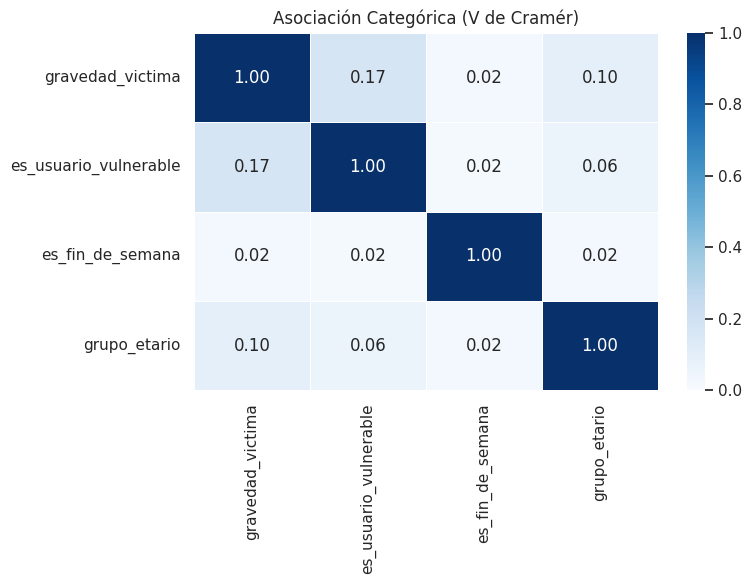

In [ ]:
print("--- EVALUACIÓN DE LAS NUEVAS CARACTERÍSTICAS (V de Cramér) ---")

# Seleccionamos nuestra variable objetivo y las 3 nuevas características
columnas_fe = ['gravedad_victima', 'es_usuario_vulnerable', 'es_fin_de_semana', 'grupo_etario']

# Reutilizamos la función que ya teníamos en memoria
generar_heatmap_cramer(df_features, columnas_fe)

MODELOS

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

print("--- FASE DE MODELADO: ÁRBOL DE DECISIÓN Y RANDOM FOREST ---")

# 1. Definición de Variables Predictores (X) y Objetivo (y)
# Actualizamos las columnas para incluir las transformaciones cíclicas que hicimos
columnas_X = [
    'es_usuario_vulnerable', 'es_fin_de_semana', # Binarias
    'mes_sin', 'mes_cos', 'dia_sin', 'dia_cos', 'hora_sin', 'hora_cos', # Cíclicas
    'edad_victima', # Numérica pura (con NaNs manejables)
    'sexo_victima', 'rol_victima', 'grupo_etario' # Categóricas
]

X = df_features[columnas_X]
y = df_features['gravedad_victima']

# 2. División de datos con Estratificación (CRÍTICO para desbalanceo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Construcción del Preprocesador Maestro
vars_numericas = [
    'es_usuario_vulnerable', 'es_fin_de_semana', 'edad_victima',
    'mes_sin', 'mes_cos', 'dia_sin', 'dia_cos', 'hora_sin', 'hora_cos'
]
vars_categoricas = ['sexo_victima', 'rol_victima', 'grupo_etario']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesador = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, vars_numericas),
        ('cat', categorical_transformer, vars_categoricas)
    ]
)

# 4. Definición de los Pipelines de los Modelos (con pesos balanceados)
pipeline_dt = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', DecisionTreeClassifier(class_weight='balanced', max_depth=7, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
])

# 5. Función de Evaluación Personalizada (F1-Macro y PR-AUC)
def evaluar_modelo(pipeline, X_train, y_train, X_test, y_test, nombre_modelo):
    print(f"\nEntrenando {nombre_modelo}...")
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test) # Necesario para PR-AUC

    print("\n" + "="*55)
    print(f"REPORTE DE CLASIFICACIÓN: {nombre_modelo.upper()}")
    print("="*55)
    print(classification_report(y_test, y_pred))

    # Cálculo de PR-AUC específicamente para la clase 'MORTAL'
    # Binarizamos las etiquetas reales para aislar la clase objetivo
    clases = pipeline.classes_
    idx_mortal = np.where(clases == 'MORTAL')[0][0]
    y_test_binario = (y_test == 'MORTAL').astype(int)
    y_proba_mortal = y_proba[:, idx_mortal]

    pr_auc_mortal = average_precision_score(y_test_binario, y_proba_mortal)
    print(f">> PR-AUC (Precision-Recall Area Under Curve) para clase MORTAL: {pr_auc_mortal:.4f}\n")

# 6. Ejecución y Evaluación
evaluar_modelo(pipeline_dt, X_train, y_train, X_test, y_test, "Árbol de Decisión")
evaluar_modelo(pipeline_rf, X_train, y_train, X_test, y_test, "Random Forest")

--- FASE DE MODELADO: ÁRBOL DE DECISIÓN Y RANDOM FOREST ---

Entrenando Árbol de Decisión...

REPORTE DE CLASIFICACIÓN: ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

       GRAVE       0.09      0.73      0.16       489
        LEVE       0.99      0.66      0.79     11571
      MORTAL       0.15      0.78      0.26       122

    accuracy                           0.66     12182
   macro avg       0.41      0.72      0.40     12182
weighted avg       0.95      0.66      0.76     12182

>> PR-AUC (Precision-Recall Area Under Curve) para clase MORTAL: 0.6112


Entrenando Random Forest...

REPORTE DE CLASIFICACIÓN: RANDOM FOREST
              precision    recall  f1-score   support

       GRAVE       0.10      0.66      0.17       489
        LEVE       0.99      0.70      0.82     11571
      MORTAL       0.17      0.78      0.28       122

    accuracy                           0.70     12182
   macro avg       0.42      0.71      0.42     12182
weighted avg

Ensembles

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, average_precision_score
import numpy as np

print("--- FASE DE MODELADO: LIGHTGBM Y XGBOOST ---")

# 1. Codificación de la Variable Objetivo (Requisito estricto de XGBoost)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

# Identificamos qué número le asignó a 'MORTAL' para calcular el PR-AUC después
# LabelEncoder ordena alfabéticamente: GRAVE=0, LEVE=1, MORTAL=2
idx_mortal_num = np.where(le.classes_ == 'MORTAL')[0][0]

# 2. Definición de los Pipelines
# LightGBM maneja el balanceo nativamente con class_weight='balanced'
pipeline_lgb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=200,
        max_depth=7,
        verbose=-1 # Para que no imprima advertencias innecesarias
    ))
])

# XGBoost requiere configurar el objetivo multiclase
pipeline_xgb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        random_state=42,
        n_estimators=200,
        max_depth=7,
        eval_metric='mlogloss'
    ))
])

# 3. Función de Evaluación Adaptada para Ensambles
def evaluar_ensemble_avanzado(pipeline, X_train, y_train_enc, X_test, y_test_enc, nombre_modelo, usar_sample_weights=False):
    print(f"\nEntrenando {nombre_modelo}...")

    # XGBoost necesita que le pasemos los pesos en el método fit
    if usar_sample_weights:
        pesos = compute_sample_weight('balanced', y_train_enc)
        pipeline.fit(X_train, y_train_enc, clasificador__sample_weight=pesos)
    else:
        pipeline.fit(X_train, y_train_enc)

    y_pred_enc = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    print("\n" + "="*55)
    print(f"REPORTE DE CLASIFICACIÓN: {nombre_modelo.upper()}")
    print("="*55)
    # Convertimos los números de vuelta a texto para que el reporte sea legible
    print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))

    # Cálculo de PR-AUC para clase MORTAL
    y_test_binario_mortal = (y_test_enc == idx_mortal_num).astype(int)
    y_proba_mortal = y_proba[:, idx_mortal_num]

    pr_auc_mortal = average_precision_score(y_test_binario_mortal, y_proba_mortal)
    print(f">> PR-AUC (Precision-Recall Area Under Curve) para clase MORTAL: {pr_auc_mortal:.4f}\n")

# 4. Ejecución y Evaluación
evaluar_ensemble_avanzado(pipeline_lgb, X_train, y_train_num, X_test, y_test_num, "LightGBM")
evaluar_ensemble_avanzado(pipeline_xgb, X_train, y_train_num, X_test, y_test_num, "XGBoost", usar_sample_weights=True)

--- FASE DE MODELADO: LIGHTGBM Y XGBOOST ---

Entrenando LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



REPORTE DE CLASIFICACIÓN: LIGHTGBM
              precision    recall  f1-score   support

       GRAVE       0.09      0.67      0.17       489
        LEVE       0.99      0.71      0.83     11571
      MORTAL       0.23      0.70      0.35       122

    accuracy                           0.71     12182
   macro avg       0.44      0.70      0.45     12182
weighted avg       0.94      0.71      0.79     12182

>> PR-AUC (Precision-Recall Area Under Curve) para clase MORTAL: 0.6465


Entrenando XGBoost...

REPORTE DE CLASIFICACIÓN: XGBOOST
              precision    recall  f1-score   support

       GRAVE       0.09      0.42      0.15       489
        LEVE       0.97      0.81      0.88     11571
      MORTAL       0.38      0.59      0.46       122

    accuracy                           0.79     12182
   macro avg       0.48      0.61      0.50     12182
weighted avg       0.93      0.79      0.85     12182

>> PR-AUC (Precision-Recall Area Under Curve) para clase MORTAL: 0.6463